In [1]:
using CairoMakie
using FFTW
include("../src-fig/plotting.jl")

[ Info: Oceananigans will use 4 threads


sponge_profile (generic function with 1 method)

In [99]:
run_id = ensemble.cooling_set.filenames[2]
#run_id = "removelargescale"
path = scratchpath
AVG = joinpath(path, run_id, "AVG.jld2")
INS = joinpath(path, run_id, "INS.jld2")
SURFACE = joinpath(path, run_id, "SURFACE.jld2")
iterations, times = iterations_times(INS)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(INS)
sp = simulation_parameters(INS);

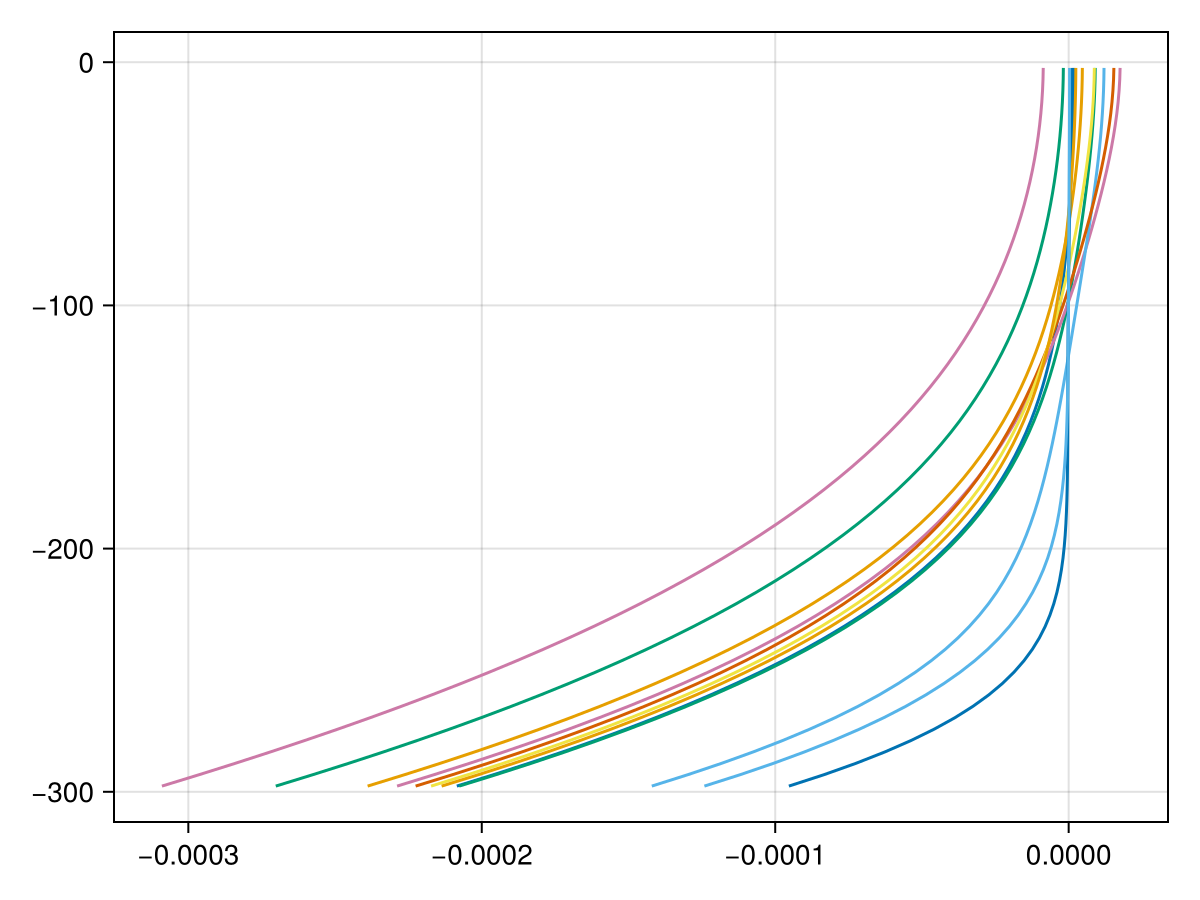

In [110]:
fig = Figure()
ax = Axis(fig[1, 1])
for iteration in iterations[2:end]
    b = get_field(INS, "b", iteration) do field
        mean(field; dims=(1, 2))[1, 1, :]
    end
    lines!(ax, b, zsᶜ)
end
fig

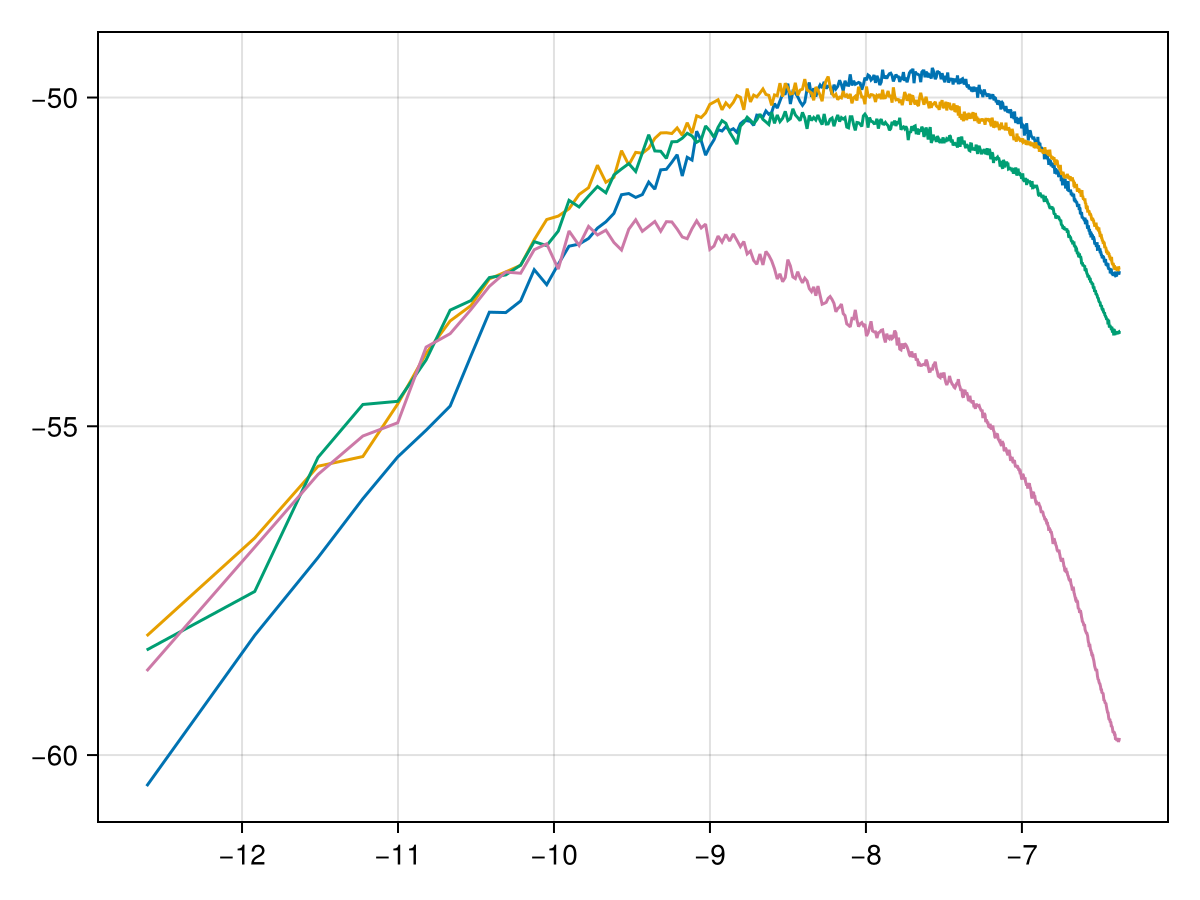

In [124]:
fig = Figure()
ax = Axis(fig[1, 1])
for run_id in ensemble.cooling_set.filenames[2:end]
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    
    b = get_field(SURFACE, "b", iterations[end])
    ks = fftfreq(sp.Nx, sp.Nx/sp.Lx)[2:512]
    b_fft = mean(abs.(fft(b, (1, ))); dims=2)[2:512, 1] .* ks
    b_fft .*= ks
    
    lines!(ax, log.(ks), 2 * log.(b_fft))
end
#lines!(ax, [-9, -7], k->-30-2(k+10); color=:black)
#lines!(ax, [-9, -7], k->-30-3(k+10); color=:black)
#lines!(ax, [-10, -7], k->-12-5(k+10); color=:black)
fig 

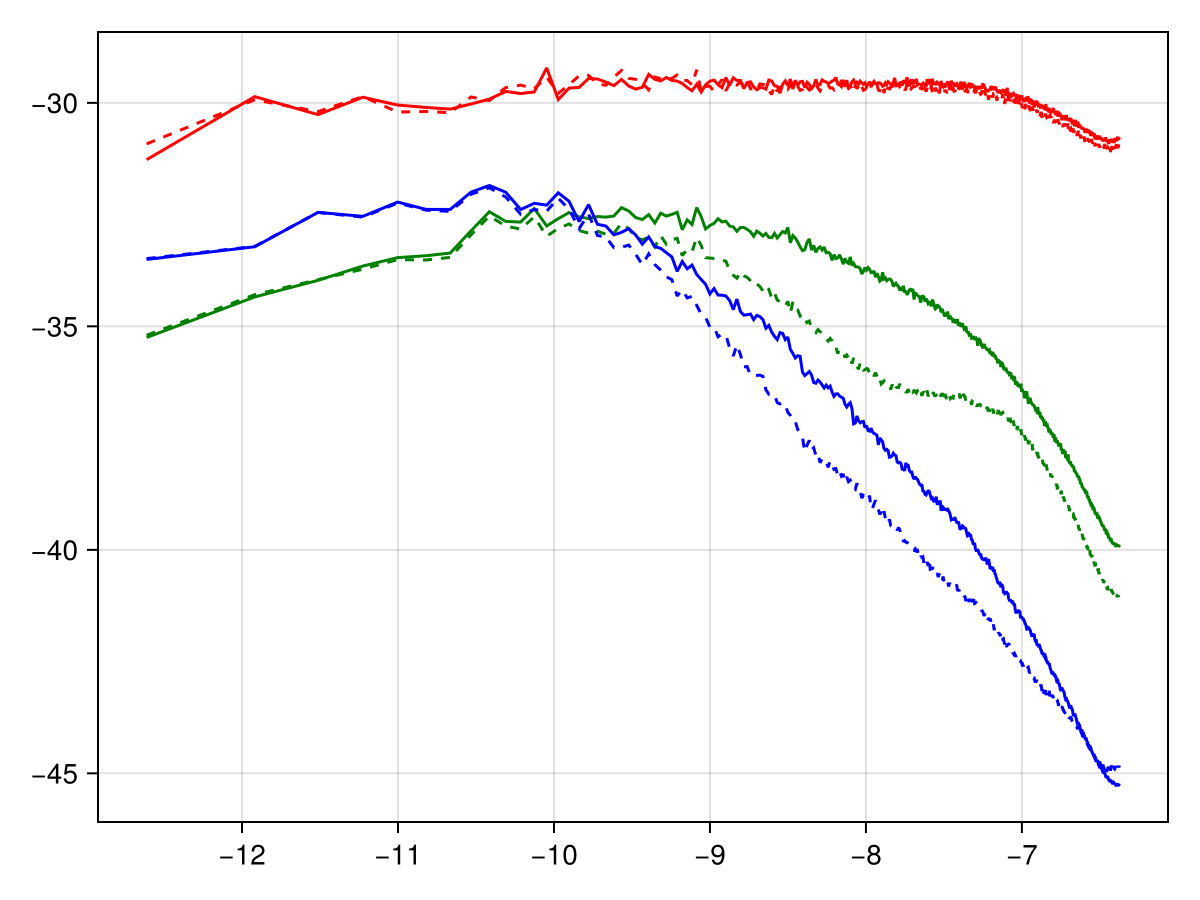

In [33]:
colors = (:red, :green, :blue)
styles = (:solid, :dash, :dot)
fig = Figure()
ax = Axis(fig[1, 1])
for (r, run_id) in enumerate(ensemble.cooling_set.filenames[[1, 2, 5]])
    color = colors[r]
    INS = joinpath(scratchpath, run_id, "INS.jld2")
    
    iterations, times = iterations_times(INS)
    sp = simulation_parameters(INS)
    for (i, l) in enumerate([64:64, 1])
        linestyle = styles[i]
        b = mean(get_field(INS, "b", iterations[end])[:, :, l]; dims=3)[:, :, 1]
        b_fft = mean(abs.(fft(b, (1,))); dims=2)[2:512, 1]
        ks = fftfreq(sp.Nx, sp.Nx/sp.Lx)[2:512]
        
        lines!(ax, log.(ks), log.(b_fft.^2 .* ks.^2); color, linestyle)
    end
end
#lines!(ax, [-10, -7], k->-8-2(k+10); color=:black)
#lines!(ax, [-10, -7], k->-10-4(k+10); color=:black)
fig

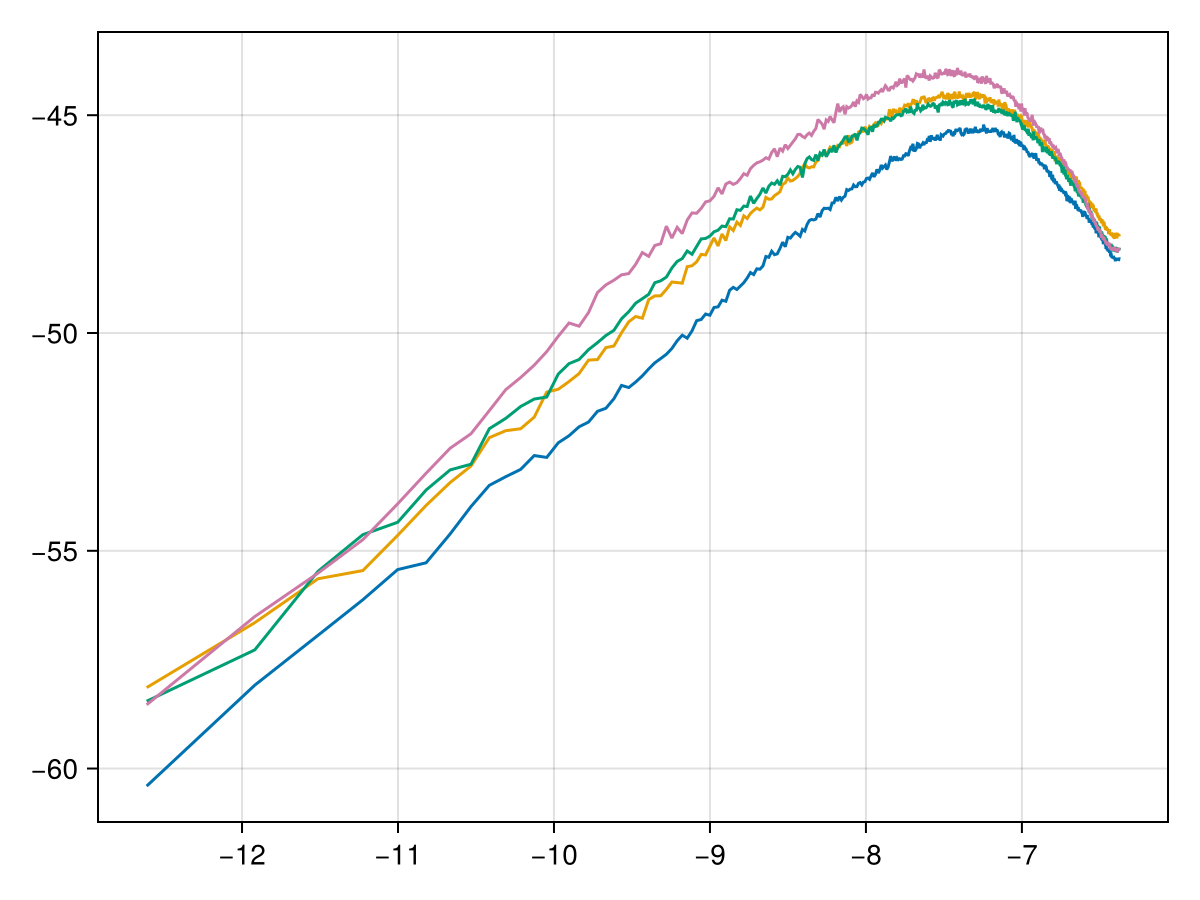

In [14]:
fig = Figure()
ax = Axis(fig[1, 1])
for run_id in ensemble.cooling_set.filenames[[2, 3, 4, 5]]
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    
    c = get_field(SURFACE, "c", iterations[end])
    ks = fftfreq(sp.Nx, sp.Nx/sp.Lx)[2:512]
    c_fft = mean(abs.(fft(c, (1,))); dims=2)[2:512, 1] .* ks
    c_fft .*= ks
    
    lines!(ax, log.(ks), 2 .* log.(c_fft))
end
#lines!(ax, [-9, -7], k->-30-2(k+10); color=:black)
#lines!(ax, [-11, -8], k->-34+1(k+11); color=:black)
fig

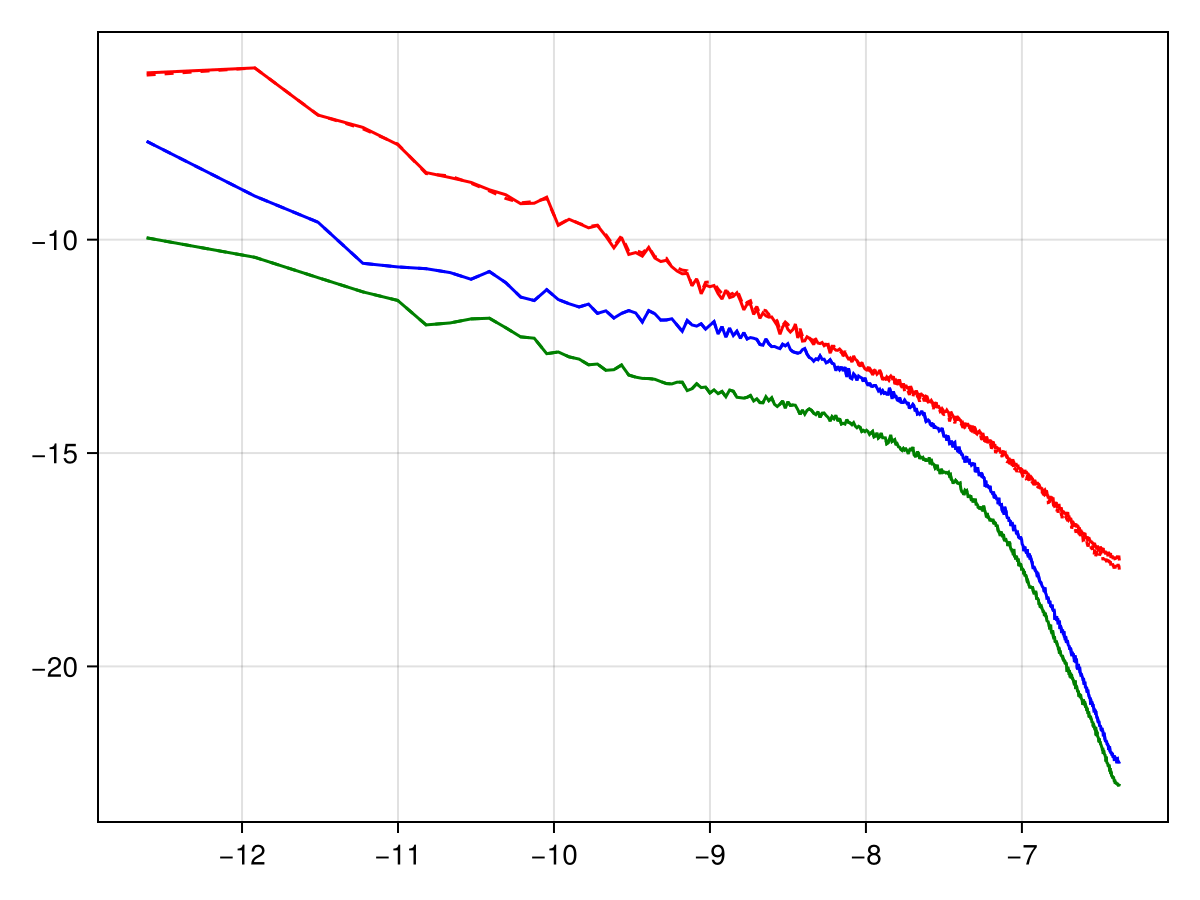

In [29]:
colors = (:red, :green, :blue)
styles = (:solid, :dash, :dot)
fig = Figure()
ax = Axis(fig[1, 1])
for (r, run_id) in enumerate(ensemble.cooling_set.filenames[1:3])
    color = colors[r]
    INS = joinpath(scratchpath, run_id, "INS.jld2")
    
    iterations, times = iterations_times(INS)
    sp = simulation_parameters(INS)
    for (i, l) in enumerate([63, 64])
        linestyle = styles[i]
        b = mean(get_field(INS, "c", iterations[end])[:, :, l]; dims=3)[:, :, 1]
        b_fft = mean(abs.(fft(b, (1,))); dims=2)[2:512, 1]
        ks = fftfreq(sp.Nx, sp.Nx/sp.Lx)[2:512]
        
        lines!(ax, log.(ks), log.(b_fft.^2); color, linestyle)
    end
end
#lines!(ax, [-10, -7], k->-8-2(k+10); color=:black)
#lines!(ax, [-10, -7], k->-10-4(k+10); color=:black)
fig

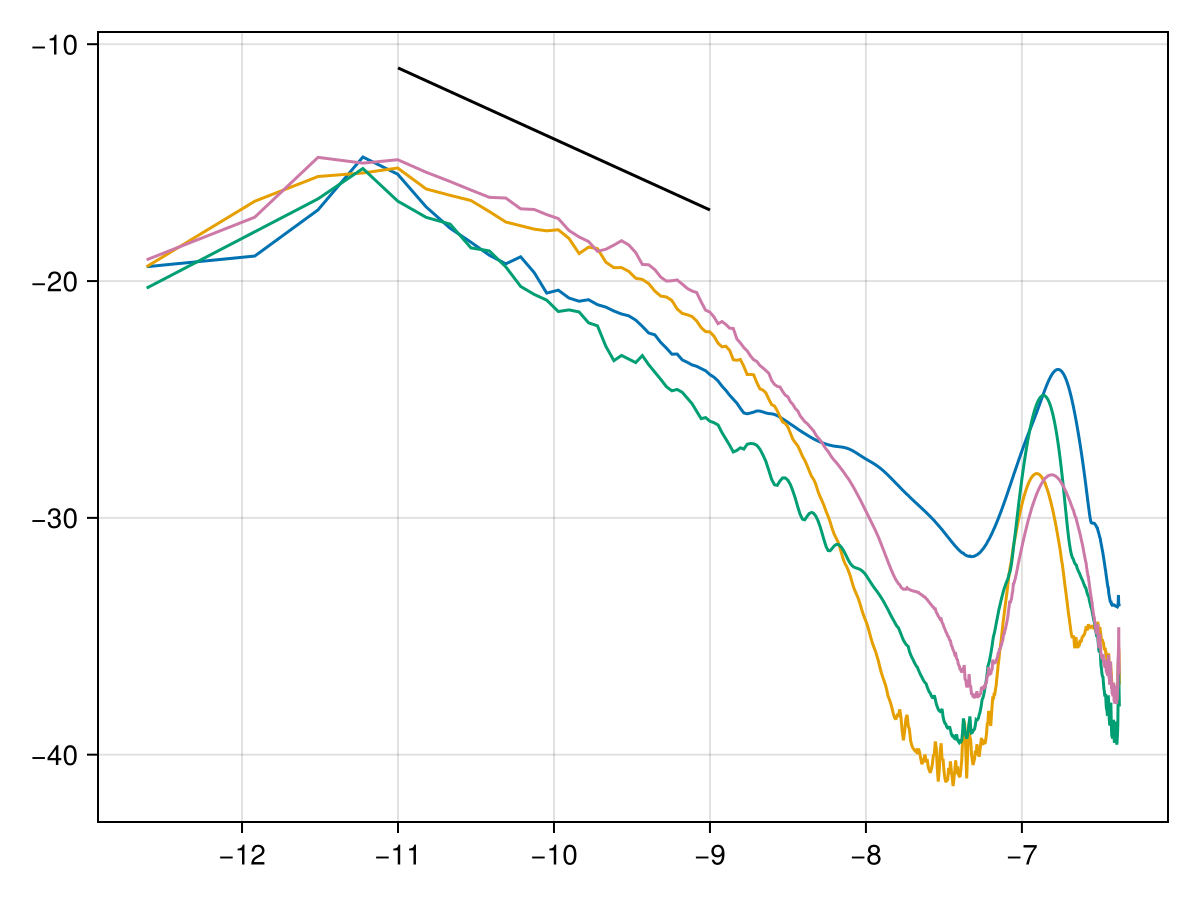

In [51]:
fig = Figure()
ax = Axis(fig[1, 1])
for run_id in ensemble.cooling_set.filenames[[2, 3, 4, 5]]
    SURFACE = joinpath(initpath, run_id, "INS.jld2")
    
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    
    c = get_field(SURFACE, "v", iterations[35]) do field
        mean(field; dims=3)[:, :, 1]
    end
    ks = fftfreq(sp.Nx, sp.Nx/sp.Lx)[2:512]
    c_fft = mean(abs.(fft(c, (1, 2))); dims=2)[2:512, 1] .* ks
    
    lines!(ax, log.(ks), 2 .* log.(c_fft))
end
#lines!(ax, [-10, -7], k->-17-5(k+9)/3; color=:black)
lines!(ax, [-11, -9], k->-17-3(k+9); color=:black)
#lines!(ax, [-9, -8], k->4-4(k+10); color=:black)
fig

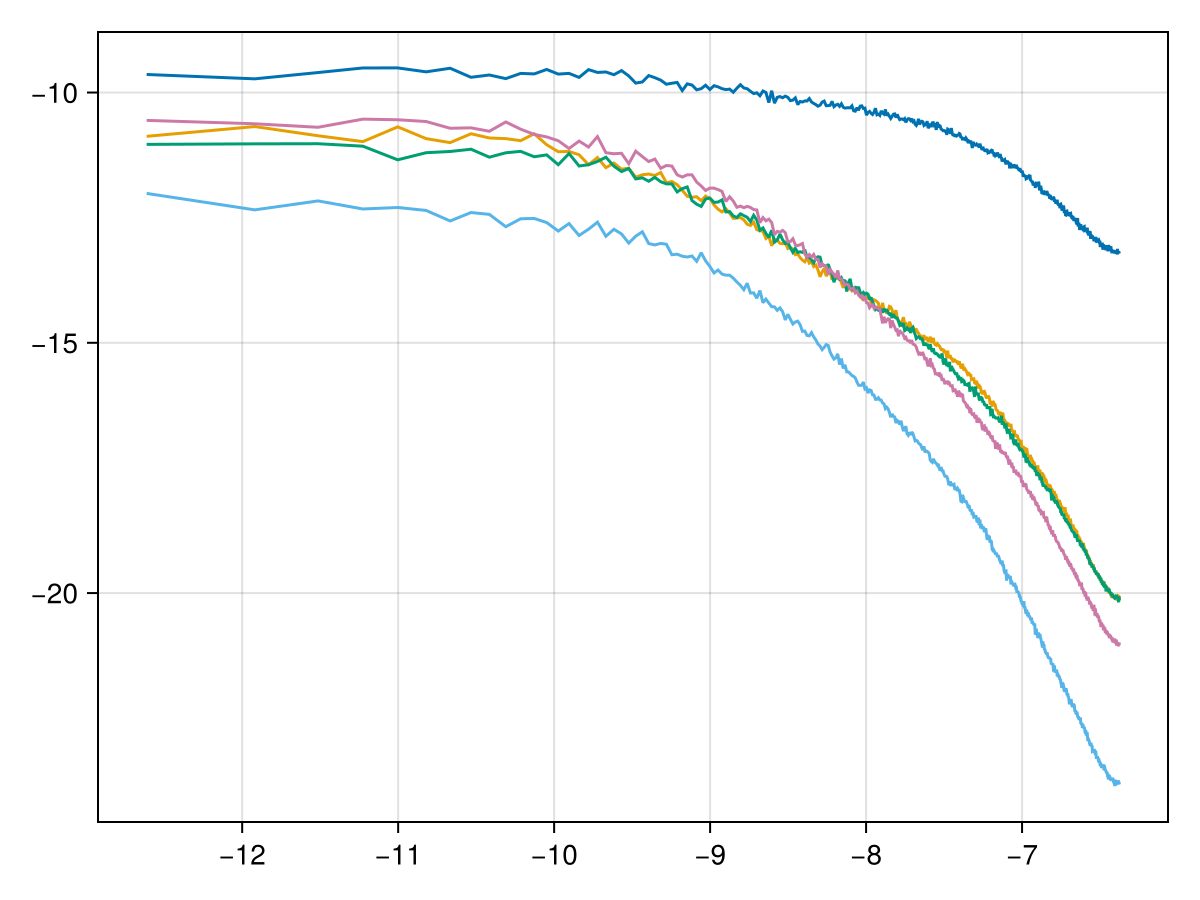

In [49]:
fig = Figure()
ax = Axis(fig[1, 1])
for run_id in ensemble.cooling_set.filenames[[1, 2, 3, 4, 5]]
    SURFACE = joinpath(scratchpath, run_id, "SURFACE.jld2")
    
    iterations, times = iterations_times(SURFACE)
    sp = simulation_parameters(SURFACE)
    u = FieldTimeSeries(SURFACE, "u"; iterations=iterations[end:end])[1]
    v = FieldTimeSeries(SURFACE, "v"; iterations=iterations[end:end])[1]
    ω = Field(∂x(v) - ∂y(u))
    c = interior(ω, :, :, 1)
    c_fft = mean(abs.(fft(c, (1,))); dims=2)[2:512, 1]
    ks = fftfreq(sp.Nx + 1, sp.Nx/sp.Lx)[2:512]
    
    lines!(ax, log.(ks), log.(c_fft.^2))
end
#lines!(ax, [-10, -7], k->5-5(k+10)/3; color=:black)
#lines!(ax, [-9, -8], k->4-4(k+10); color=:black)
fig